In [1]:
import json
import pandas as pd

fta_tr = []
with open("SFT dataset/fairy tale qa/train.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            fta_tr.append(json.loads(line))
df_fta_tr = pd.DataFrame(fta_tr)[['content', 'answer', 'question']]

fta_ts = []
with open("SFT dataset/fairy tale qa/test.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            fta_ts.append(json.loads(line))
df_fta_ts = pd.DataFrame(fta_ts)[['content', 'answer', 'question']]

fta_val = []
with open("SFT dataset/fairy tale qa/valid.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            fta_val.append(json.loads(line))
df_fta_val = pd.DataFrame(fta_val)[['content', 'answer', 'question']]

df_fta = pd.concat([df_fta_tr,df_fta_ts,df_fta_val]).reset_index(drop=True)

del(fta_tr)
del(fta_ts)
del(fta_val)

In [2]:
tmw_tr = []
with open("SFT dataset/tell me why/train.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            tmw_tr.append(json.loads(line))
df_tmw_tr = pd.DataFrame(tmw_tr)[['narrative', 'answer', 'question']]

tmw_ts = []
with open("SFT dataset/tell me why/test.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            tmw_ts.append(json.loads(line))
df_tmw_ts = pd.DataFrame(tmw_ts)[['narrative', 'answer', 'question']]

tmw_val = []
with open("SFT dataset/tell me why/validation.json", "r") as f:
    for line in f:
        if line.strip():  # skip empty lines
            tmw_val.append(json.loads(line))
df_tmw_val = pd.DataFrame(tmw_val)[['narrative', 'answer', 'question']]

df_tmw = pd.concat([df_tmw_tr,df_tmw_ts,df_tmw_val]).reset_index(drop=True).rename(columns={'narrative':'content'})

del(tmw_tr)
del(tmw_ts)
del(tmw_val)

In [3]:
import re

def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

df = pd.concat([df_fta,df_tmw]).reset_index(drop=True)
df['content'] = df['content'].apply(lambda x: clean_text(x))
df['question'] = df['question'].apply(lambda x: clean_text(x))
df['answer'] = df['answer'].apply(lambda x: clean_text(x))
del(df_fta)
del(df_tmw)
df

,content,answer,question
0,once upon a time there was a king who went for...,the people wished their king all that was good .,why was there great rejoicing in the city and ...
1,once upon a time there was a king who went for...,kind and just .,what type of ruler was the king ?
2,once upon a time there was a king who went for...,a strange - looking old woman .,who entered the room while the child lay in it...
3,once upon a time there was a king who went for...,be allowed out under the open sky until she we...,what did the old woman say the child must not ...
4,once upon a time there was a king who went for...,the mountain troll would fetch her .,what would happen if the child went under the ...
...,...,...,...
102132,cindy and her children were visiting the uk fo...,she ask him where the closest beach was located.,why did he direct her?
102133,cindy and her children were visiting the uk fo...,she visited the beach.,why did cindy discover that shingle meant larg...
102134,cindy and her children were visiting the uk fo...,cindy needed directions to the beach.,why did cindy ask a local man?
102135,cindy and her children were visiting the uk fo...,the man knew how cindy could get to the beach.,why did he direct her?


In [4]:
tiny_stories = df['content'] + df['question'] + df['answer'] 

In [5]:
import numpy as np
from tqdm.auto import tqdm
import re

# Combine summary + dialogue and split on whitespace
raw_lens = [len(s.split()) for s in tqdm(tiny_stories, total=len(tiny_stories))]

lens = np.array(raw_lens)

# Print summary stats
def pct(x): return np.percentile(lens, x)

print(f"Total examples    : {len(lens):,}")
print(f"Min / Max words   : {lens.min()} / {lens.max()}")
print(f"Mean ± std        : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- Percentiles (word count per raw text pair) ---")
for p in [50, 55, 60, 70, 80, 90, 95, 99]:
    print(f"{p:>3}% : {pct(p):.0f} words")

/Users/saptarshimallikthakur/Pictures/VLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 102137/102137 [00:00<00:00, 507834.12it/s]

Total examples    : 102,137
Min / Max words   : 26 / 1575
Mean ± std        : 76.4 ± 69.1
--- Percentiles (word count per raw text pair) ---
 50% : 58 words
 55% : 60 words
 60% : 61 words
 70% : 65 words
 80% : 70 words
 90% : 100 words
 95% : 229 words
 99% : 368 words


In [6]:
MAX_LEN = int(pct(90)) + 4 # BOS,QUES,SEP,EOS

stories = []
index = []

for i,story in enumerate(tiny_stories):
    try:
        if len(story.strip().split()) < MAX_LEN: 
            stories.append(story)
            index.append(i)
    except:
        pass

del(lens)
del(raw_lens)
del(tiny_stories)

In [7]:
df = df[df.index.isin(index)].reset_index(drop=True)
df

,content,answer,question
0,""" this is the princess , "" said boots . and so...",the king could think of nothing more to set bo...,why did the king let boots marry the princess ?
1,a crowd as large as that at a fair at once gat...,all wanted to buy the pig .,why did a crowd gather ?
2,a crowd as large as that at a fair at once gat...,a gentleman .,who came along and whispered something to the ...
3,"not far from baalsberg , near filkestad in the...",stompe pilt .,who used to live on a hill not far from baalsb...
4,"not far from baalsberg , near filkestad in the...",driving his flock up the hill in which stompe ...,what was a goat-herd doing one day ?
...,...,...,...
92004,cindy and her children were visiting the uk fo...,she ask him where the closest beach was located.,why did he direct her?
92005,cindy and her children were visiting the uk fo...,she visited the beach.,why did cindy discover that shingle meant larg...
92006,cindy and her children were visiting the uk fo...,cindy needed directions to the beach.,why did cindy ask a local man?
92007,cindy and her children were visiting the uk fo...,the man knew how cindy could get to the beach.,why did he direct her?


In [8]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("Pre-Trained Directory/tokenizer.json")

In [9]:
VOCAB_SIZE = tokenizer.get_vocab_size()
SPECIAL_TOKENS = ['[PAD]', '[UNK]','[BOS]', '[EOS]', '[SEP]','[IMG_TOKEN]']

In [10]:
from tokenizers.processors import TemplateProcessing

# 3) Configure post-processing, padding & truncation ------------------
pad_id = tokenizer.encode('[PAD]').ids[0]
unk_id = tokenizer.encode('[UNK]').ids[0]
bos_id = tokenizer.encode('[BOS]').ids[0]
eos_id = tokenizer.encode('[EOS]').ids[0]
sep_id = tokenizer.encode('[SEP]').ids[0]
img_token_id = tokenizer.encode('[IMG_TOKEN]').ids[0]

# Add BOS/EOS around single sequences
tokenizer.post_processor = TemplateProcessing(
    single='$A',
    special_tokens=[],
)

Total samples    : 92,009
Min / Max tokens : 38 / 139
Mean ± std       : 74.1 ± 12.8
--- percentiles (tokens) ---
 50% : 74
 60% : 77
 70% : 80
 80% : 85
 90% : 91
 95% : 96
 99% : 106


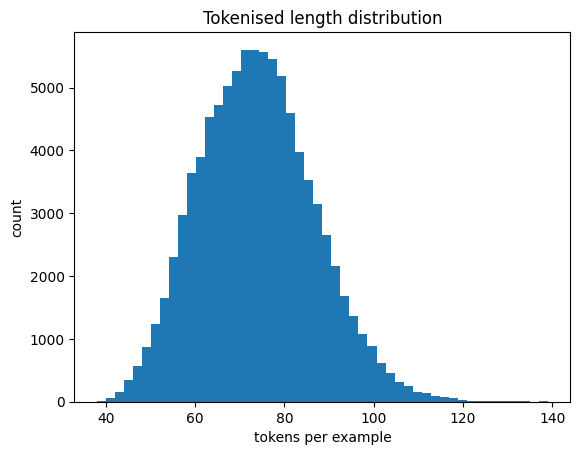

In [11]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0)  Make sure `tok` points to the FINAL tokenizer
#     → trained on the full corpus with your chosen vocab_size
# ------------------------------------------------------------
tok = tokenizer          # whatever variable you use

# ------------------------------------------------------------
# 1)  Get token counts for every example
#     (here: concatenate summary + dialogue; split if you want)
# ------------------------------------------------------------
lens = []

for txt in stories:
    ids   = tok.encode(txt).ids
    lens.append(len(ids))

lens = np.array(lens)

# ------------------------------------------------------------
# 2)  Print key stats
# ------------------------------------------------------------
def pct(x): return np.percentile(lens, x)

print(f"Total samples    : {len(lens):,}")
print(f"Min / Max tokens : {lens.min()} / {lens.max()}")
print(f"Mean ± std       : {lens.mean():.1f} ± {lens.std():.1f}")
print("--- percentiles (tokens) ---")
for p in (50, 60, 70, 80, 90, 95, 99):
    print(f"{p:>3}% : {pct(p):.0f}")

# ------------------------------------------------------------
# 3)  Quick histogram    (no seaborn, single plot, no colors set)
# ------------------------------------------------------------
plt.hist(lens, bins=50)
plt.xlabel("tokens per example")
plt.ylabel("count")
plt.title("Tokenised length distribution")
plt.show()

In [12]:
BATCH_SIZE = 32
MAX_LEN = 128
del(lens)
del(stories)

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len, bos_id, sep_id, eos_id, pad_id):
        self.texts = texts  # List of (context, question, answer) tuples
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.bos_id = bos_id
        self.sep_id = sep_id
        self.eos_id = eos_id
        self.pad_id = pad_id

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        context, question, answer = self.texts[idx]

        # Encode on-the-fly
        para = self.tokenizer.encode(context)
        q = self.tokenizer.encode(question)
        a = self.tokenizer.encode(answer)

        # Combine tokens
        ids = [self.bos_id] + para.ids + q.ids + [self.sep_id] + a.ids

        # Truncate
        ids = ids[:self.max_len]

        # Prepare labels
        labels = ids[1:] + [self.eos_id]

        # Pad to max_len
        ids += [self.pad_id] * (self.max_len - len(ids))
        labels += [self.pad_id] * (self.max_len - len(labels))

        # Convert to tensors
        ids_t = torch.tensor(ids, dtype=torch.long)
        labels_t = torch.tensor(labels, dtype=torch.long)

        # Compute loss mask
        sep_pos = (labels_t == self.sep_id).nonzero(as_tuple=False)
        sep_pos = sep_pos[0, 0] if len(sep_pos) else self.max_len
        loss_mask = ((torch.arange(self.max_len) > sep_pos) & (labels_t != self.pad_id)).float()

        return {
            "input_ids": ids_t,
            "labels": labels_t,
            "loss_mask": loss_mask
        }

# Usage
texts = list(zip(df['content'].values, df['question'].values, df['answer'].values))
dataset = TextDataset(
    texts=texts,
    tokenizer=tokenizer,
    max_len=MAX_LEN,
    bos_id=bos_id,
    sep_id=sep_id,
    eos_id=eos_id,
    pad_id=pad_id
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# del(texts)
# del(df)
# del(dataset)

In [14]:
vocab = tokenizer.get_vocab()           # indices 0 … V

id_to_token = {idx: tok for tok, idx in vocab.items()}

# 2) Decoder: drop PADs, replace unknown IDs with '?'
def decode_token_ids(token_ids: list[int]) -> str:
    tokens = []
    for tid in token_ids:
        if tid == pad_id:
            continue
        tokens.append(id_to_token.get(tid, '?'))
    return ' '.join(tokens)

# Take one batch
batch = next(iter(loader))

input_ids = batch['input_ids']   # shape: [B, MAX_LEN]
labels    = batch['labels']      # shape: [B, MAX_LEN]

for i in range(input_ids.size(0)):
    ids_row = input_ids[i].tolist()
    lbl_row = labels[i].tolist()

    print(f"\n🟢 Sample {i+1}")
    print("  Input IDs: ", ids_row)
    print("  Decoded input:   ", decode_token_ids(ids_row))  # Assumes you have this function defined
    print("  Decoded label:   ", decode_token_ids(lbl_row))  # Assumes you have this function defined
    print("  Label IDs: ", lbl_row)


🟢 Sample 1
  Input IDs:  [2, 79, 135, 507, 115, 534, 197, 11704, 3941, 19, 110, 338, 131, 176, 196, 233, 19, 110, 3099, 70, 1371, 868, 17, 11758, 17, 118, 70, 4171, 19, 110, 338, 131, 118, 110, 453, 131, 145, 1831, 19, 110, 659, 110, 1570, 12, 89, 387, 131, 528, 1428, 19, 556, 309, 110, 676, 131, 36, 4, 110, 507, 115, 648, 534, 11704, 3941, 19, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Decoded input:    [BOS] j ay wanted to try out dairy queen . he ate it with his friend . he bought a bur ger , fries , and a shake . he ate it and he thought it was okay . he decided he wouldn ' t get it again though . why did he eat it ? [SEP] he wanted to always try dairy queen .
  Decoded label:    j ay wanted to try out dairy queen . he ate it with his friend . he bought a bur ger , fries , and a shake . he ate it and he thought it was okay . he decided

In [15]:
from model import *

device='mps'

class BuildTransformer(torch.nn.Module):
    def __init__(self, *, num_layers, d_model, num_heads, input_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size=input_vocab_size, d_model=d_model)
        self.decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                               input_vocab_size=input_vocab_size, dropout_rate=dropout_rate)

    def forward(self, inputs):
        x = inputs
        # Create padding mask (True for padding tokens, False otherwise)
        pad_mask = (x == 0)  # Assuming padding token is 0, as in TokenEmbedding's padding_idx
        x = self.token_embedding(x)
        x = self.decoder(x, pad_mask=pad_mask)
        return x

# Example instantiation
num_layers = 3
d_model = 256
num_heads = 8  # 32 dim per head
dropout_rate = 0.1

model = BuildTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    input_vocab_size=tokenizer.get_vocab_size(),
    dropout_rate=dropout_rate
)

model.to(device)

# Build weights by running a forward pass
dummy = torch.zeros((1, MAX_LEN), dtype=torch.int32).to(device)
_ = model(dummy)

model.load_state_dict(torch.load('Pre-Trained Directory/pretrained_weights.pth'))

<All keys matched successfully>

In [16]:
print("Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Trainable Parameters: {total_params:,}")

Trainable Parameters:
------------------------------------------------------------
Parameter: token_embedding.embedding.weight                   Shape: torch.Size([12000, 256]) Parameters: 3072000
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wq.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wk.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wv.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.mha.wo.weight Shape: torch.Size([256, 256]) Parameters: 65536
Parameter: decoder.dec_layers.0.causal_self_attention.rmsnorm.scale Shape: torch.Size([256])    Parameters: 256
Parameter: decoder.dec_layers.0.ffn.swiglu.lin1.weight        Shape: torch.Size([1024, 256]) Parameters: 262144
Parameter: decoder.dec_layers.0.ffn.swiglu.lin2.weight        Shape: torch.Size([256, 512]) Parameters: 131072
Para

In [17]:
print("Non Trainable Parameters:")
print("-" * 60)
total_params = 0
for name, param in model.named_parameters():
    if not param.requires_grad:
        param_count = param.numel()
        print(f"Parameter: {name:<50} Shape: {str(param.shape):<20} Parameters: {param_count}")
        total_params += param_count
print("-" * 60)
print(f"Total Non Trainable Parameters: {total_params:,}")

Non Trainable Parameters:
------------------------------------------------------------
------------------------------------------------------------
Total Non Trainable Parameters: 0


In [ ]:
from torch.optim.lr_scheduler import _LRScheduler
import math
from tqdm import tqdm
import torch

class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, total_steps, warmup_steps_ratio, min_lr, max_lr, last_epoch=-1):
        self.total_steps = total_steps
        self.warmup_steps = int(total_steps * warmup_steps_ratio)
        self.min_lr = min_lr
        self.max_lr = max_lr
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        current_step = self.last_epoch
        if current_step < self.warmup_steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (current_step / self.warmup_steps)
        else:
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            decay_factor = math.exp(-1.0 * progress)
            lr = self.min_lr + (self.max_lr - self.min_lr) * decay_factor
            lr = max(lr, self.min_lr)
        return [lr for _ in self.base_lrs]

EPOCHS = 3
LEARNING_RATE_MIN = 1e-6
LEARNING_RATE_MAX = 1e-5
WARMUP_RATIO = 0.1

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_MAX, betas=(0.9, 0.98), eps=1e-9)
criterion = torch.nn.CrossEntropyLoss(reduction='none')  

# --- Calculate total steps and initialize scheduler ---
total_steps = len(loader) * EPOCHS
scheduler = CustomLRScheduler(
    optimizer,
    total_steps=total_steps,
    warmup_steps_ratio=WARMUP_RATIO,
    min_lr=LEARNING_RATE_MIN,
    max_lr=LEARNING_RATE_MAX
)

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_loss = tot_correct = tot_tokens = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=True)
    for batch in pbar:
        ids = batch["input_ids"].to(device)          # (B, T)
        tgt = batch["labels"].to(device)             # (B, T)
        mask = batch["loss_mask"].to(device)         # (B, T)

        optimizer.zero_grad()
        logits = model(ids)                          # (B, T, V)

        # ---- loss ----
        loss = criterion(logits.view(-1, logits.size(-1)), tgt.view(-1))  # (B*T,)
        masked_loss = (loss * mask.view(-1)).sum() / mask.sum().clamp(min=1)  # Apply mask and average
        masked_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        # ---- metrics (no grad) ----
        with torch.no_grad():
            preds = logits.argmax(-1)                # (B, T)
            valid = (mask == 1.0)                    # bool mask where loss_mask is 1.0
            correct = (preds == tgt) & valid         # Correct predictions where mask is 1.0
            n_tok = valid.sum().item()               # Count of masked tokens

            tot_correct += correct.sum().item()
            tot_tokens += n_tok
            tot_loss += masked_loss.item() * n_tok   # Scale by number of valid tokens

        pbar.set_postfix(
            loss=f"{tot_loss / tot_tokens:.4f}" if tot_tokens > 0 else "N/A",
            acc=f"{tot_correct / tot_tokens:.4f}" if tot_tokens > 0 else "N/A",
            lr=f"{scheduler.get_last_lr()[0]:.6f}"
        )

Epoch 3/3: 100%|██████████| 2875/2875 [08:29<00:00,  5.64it/s, acc=0.3926, loss=3.4812, lr=0.000004]


In [19]:
torch.save(model.state_dict(), 'finetuned directory/finetuned_weights.pth')

torch.save(
    {"token_embedding": model.token_embedding.state_dict()},
    "finetuned directory/finetuned_embedding_dict.pth"
)

torch.save(
    {"decoder": model.decoder.state_dict()},
    "finetuned directory/finetuned_decoder_dict.pth"
)

In [20]:
def encode_input(context: str, question: str) -> torch.Tensor:
    """
    Returns [BOS] dialogue [EOS] *without* any padding.
    """
    ids = [bos_id] + tokenizer.encode(clean_text(context)).ids + tokenizer.encode(clean_text(question)).ids + [sep_id]        
    return torch.tensor(ids, dtype=torch.int32)     # 1-D tensor

@torch.no_grad()
def generate_summary(
    text_ids: torch.Tensor,
    model: torch.nn.Module,
    max_new: int = 50,
    temperature: float = 0.5,
    device: str = "cpu"
) -> torch.Tensor:
    """
    Generate tokens auto-regressively: [BOS] text [EOS]
    """
    model.eval()
    input_len = text_ids.size(0)
    prompt = text_ids.unsqueeze(0).to(device)  # (1, T)
    for _ in range(max_new):
        if prompt.shape[1] > 300:                
            break

        logits = model(prompt)[:, -1, :] / temperature
        next_id = torch.distributions.Categorical(logits=logits).sample().unsqueeze(0)
        prompt = torch.cat([prompt, next_id], dim=1)

        if next_id[0, 0] == eos_id:
            break

    return prompt.squeeze(0)[input_len:]

def display_text(context: str, question: str, model, device="cpu"):
    # 1. Encode input
    text_ids = encode_input(context,question)

    # 2. Generate full sequence
    full_ids = generate_summary(text_ids, model, device=device)

    # 3. Convert to list
    full_ids_list = full_ids.tolist()

    # 4. Decode
    text_str = decode_token_ids(full_ids_list)

    # 5. Print
    return text_str

In [21]:
import numpy as np

for i in np.random.randint(0,90000,10):
    print('\n Content : ',df['content'][i])
    print('Question asked : ',df['question'][i])
    print('Original Answer : ',df['answer'][i])
    print('Generated Answer : ',display_text(df['content'][i],df['question'][i],model, device='mps'))
    print('********************************************************************************')


# import numpy as np

# # Output file path
# output_file = "sampled_results.txt"

# with open(output_file, 'w', encoding='utf-8') as f:
#     for i in np.random.randint(0, len(loader)*(BATCH_SIZE), 100):
#         content = df['content'][i]
#         question = df['question'][i]
#         original_answer = df['answer'][i]
#         generated_answer = display_text(content, question, model, device='mps')

#         f.write(f"\nContent:\n{content}\n")
#         f.write(f"Question asked:\n{question}\n")
#         f.write(f"Original Answer:\n{original_answer}\n")
#         f.write(f"Generated Answer:\n{generated_answer}\n")
#         f.write("********************************************************************************\n")

# print(f"Results saved to {output_file}")


 Content :  i went into the kitchen to cook dinner. i put vegetables and a knife on the counter. i began to cut into the vegetables with the knife. i felt a sharp pain and saw a dark red liquid. i looked down to see that i had deeply cut my finger.
Question asked :  why did i begin to cut into the vegetables with the knife?
Original Answer :  it was easier to cook vegetables in smaller pieces.
Generated Answer :  i wanted to eat them . [EOS]
********************************************************************************

 Content :  karen was taking a taxi to the store. when they arrived the driver realized he hadn't set the meter. they had no clue how much it cost. he waved karen off, saying that it was on the house. karen hesitated but then thanked him.
Question asked :  why did karen hesitate but?
Original Answer :  she didn't want to abuse the taxi driver's generosity.
Generated Answer :  he wanted to get a car . [EOS]
*************************************************************

# TESTING TEXT GENERATION 

In [22]:
from model import *
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("Pre-Trained Directory/tokenizer.json")

device='mps'

class BuildTransformer(torch.nn.Module):
    def __init__(self, *, num_layers, d_model, num_heads, input_vocab_size, dropout_rate=0.1):
        super().__init__()
        self.token_embedding = TokenEmbedding(vocab_size=input_vocab_size, d_model=d_model)
        self.decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                               input_vocab_size=input_vocab_size, dropout_rate=dropout_rate)

    def forward(self, inputs):
        x = inputs
        # Create padding mask (True for padding tokens, False otherwise)
        pad_mask = (x == 0)  # Assuming padding token is 0, as in TokenEmbedding's padding_idx
        x = self.token_embedding(x)
        x = self.decoder(x, pad_mask=pad_mask)
        return x

# Example instantiation
num_layers = 3
d_model = 256
num_heads = 8  # 32 dim per head
dropout_rate = 0.1

model = BuildTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    input_vocab_size=tokenizer.get_vocab_size(),
    dropout_rate=dropout_rate
)

model.to(device)

# Build weights by running a forward pass
dummy = torch.zeros((1, MAX_LEN), dtype=torch.int32).to(device)
_ = model(dummy)

model.load_state_dict(torch.load('finetuned directory/finetuned_weights.pth'))

<All keys matched successfully>

In [23]:
import re

bos_id = tokenizer.encode('[BOS]').ids[0]
eos_id = tokenizer.encode('[EOS]').ids[0]
pad_id = tokenizer.encode('[PAD]').ids[0]

def clean_text(text: str) -> str:
    """
    Remove HTML, normalize whitespace, preserve punctuation/numbers/casing.
    """
    text = text.replace('\r', ' ').replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

vocab = tokenizer.get_vocab()           # indices 0 … V

id_to_token = {idx: tok for tok, idx in vocab.items()}

# 2) Decoder: drop PADs, replace unknown IDs with '?'
def decode_token_ids(token_ids: list[int]) -> str:
    tokens = []
    for tid in token_ids:
        if tid == pad_id:
            continue
        tokens.append(id_to_token.get(tid, '?'))
    return ' '.join(tokens)

def encode_input(text: str) -> torch.Tensor:
    """
    Returns [BOS] dialogue [EOS] *without* any padding.
    """
    ids = [bos_id] + tokenizer.encode(clean_text(text)).ids             
    return torch.tensor(ids, dtype=torch.int32)     # 1-D tensor

@torch.no_grad()
def generate_summary(
    text_ids: torch.Tensor,
    model: torch.nn.Module,
    max_new: int = 70,
    temperature: float = 1,
    device: str = "cpu"
) -> torch.Tensor:
    """
    Generate tokens auto-regressively: [BOS] text [EOS]
    """
    model.eval()

    prompt = text_ids.unsqueeze(0).to(device)  # (1, T)
    for _ in range(max_new):

        logits = model(prompt)[:, -1, :] / temperature
        next_id = torch.distributions.Categorical(logits=logits).sample().unsqueeze(0)
        prompt = torch.cat([prompt, next_id], dim=1)

        if next_id[0, 0] == eos_id:
            break

    return prompt.squeeze(0)

def display_text(text: str, model, temp=1, device="cpu"):
    # 1. Encode input
    text_ids = encode_input(text)

    # 2. Generate full sequence
    full_ids = generate_summary(text_ids, model, temperature=temp, device=device)

    # 3. Convert to list
    full_ids_list = full_ids.tolist()

    # 4. Decode
    text_str = decode_token_ids(full_ids_list)

    # 5. Print
    print("Text:", text_str)

In [24]:
display_text('john went to forest',model,device='mps',temp=1)

Text: [BOS] jo h n went to forest . to a climbing , a horse of snow ed on its r ave k . [EOS]


In [25]:
display_text('lily was studying math ',model,device='mps',temp=1)

Text: [BOS] lily was studying math library es included and that was considered one of the laptop from fortunately . [EOS]


In [26]:
display_text('given an image of boy standing by river what might he be thinking ?',model,device='mps',temp=1)

Text: [BOS] given an image of boy standing by river what might he be thinking ? [EOS]


In [27]:
display_text('given sara sat on a bike where was she going ?',model,device='mps',temp=1)

Text: [BOS] given s ara sat on a bike where was she going ? she had invited her bike for a walk . [EOS]
